In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('data/M3_data2_regression.csv')
data.head(5)

,Unnamed: 0,x0,x1,y
0,0,1.0,-3.203110,19.951346
1,1,1.0,5.843709,63.990991
2,2,1.0,8.592693,27.237021
3,3,1.0,-0.773814,52.837923
4,4,1.0,1.054070,119.761951


#### Gradient_descent function takes the following parameters 

- features
- labels
- eta: learning rate, or step size
- T: number of iterations

#### It returns the following:
- parameters (i.e. weights)
- array of updated loss-value after each iteration. 

In [3]:
def gradient_descent(features, labels, eta, T):
    losses = []
    params = np.zeros(features.shape[1])
    for t in range(T):
        predictions = np.dot(features, params) 
        errors = predictions - labels #calculate error
        grad = (2 / len(labels)) * np.dot(features.T, errors)
        params = params - eta * grad #update params
        loss = np.sum(errors ** 2)
        losses.append(loss)
    return params, losses

#### Test with a tiny data set for y = 2x + 1

In [4]:
X = np.array([[1, 1], [1, 2], [1, 3], [1, 4]])  #this aligns with dataset used in this example with x0 as 1 for all rows
y = np.array([3, 5, 7, 9])
params, losses = gradient_descent(X, y, 0.01, T=1000)
print(params)

[0.98570802 2.00486102]


#### Analyze gradient descent at different learning rates

In [5]:
features = data[['x0', 'x1']].values
labels = data['y'].values
eta = 0.01
T = 1000
params1, losses1 = gradient_descent(features, labels, eta, T)
print(params1)

[ 5.83008101 15.2234794 ]


In [6]:
eta = 0.001
T = 1000
params2, losses2 = gradient_descent(features, labels, eta, T)
print(params2)

[ 5.0266635  15.21814363]


In [7]:
eta = 0.0001
T = 1000
params3, losses3 = gradient_descent(features, labels, eta, T)
print(params3)

[ 0.97302605 15.17561417]


#### Plot gradient_descent for the loss function

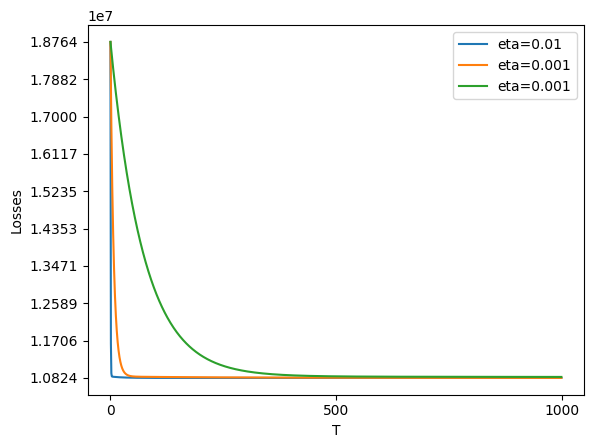

In [8]:
plt.xticks(np.arange(0, len(losses1)+1, 500))
plt.yticks(np.linspace(min(losses1), max(losses1), 10))
plt.plot(range(len(losses1)), losses1, label='eta=0.01')
plt.plot(range(len(losses2)), losses2, label='eta=0.001')
plt.plot(range(len(losses3)), losses3, label='eta=0.001')
plt.xlabel("T")
plt.ylabel("Losses")
plt.legend()
plt.show()